# Diagnostics -- pixel traces multiresolution + SVD (optimisation) + Hilbert

Visualise le contenu d'un fichier `pixel_svd_diagnostics.npz` produit par
`compute_one_cycle_pixel_svd.py` (dossier `Astronauts/`, meme dossier que ce
notebook). Change simplement `NPZ_PATH` ci-dessous pour regarder une autre
condition / variante de segmentation.

Groupes de figures, dans l'ordre de la chaine de traitement :

  0. pouls mesure (`Data Files/visit_data.csv`) vs frequence cardiaque estimee ;
  A. masque de selection des pixels, sur une image moyennee de la video ;
  B. vecteurs singuliers (SVD, sans passe-bande ni normalisation), domaine
     temporel ET frequentiel ;
  C. combinaison optimisee de ces vecteurs (`OptimizedSpectralCombination`),
     domaine temporel ET frequentiel, avec la bande d'optimisation, le pic
     de frequence cardiaque cible ET le pouls mesure (visit_data) ;
  D. phase obtenue par transformee de Hilbert sur ce signal agrege.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Pointe vers un pixel_svd_diagnostics.npz ecrit par compute_one_cycle_pixel_svd.py,
# p.ex. sous SEGVAR_ROOT/<variante>/pixel_svd_one_cycle/<astro>/<moment>/<condition>/.
NPZ_PATH = Path(
    "E:/NASA_Rigidity/SegmentationVariations/model1_scale_2.0/pixel_svd_one_cycle/"
    "01_210713001/210713001before_rigidity/210713001before_rigidity_OD/"
    "pixel_svd_diagnostics.npz"
)

d = np.load(NPZ_PATH, allow_pickle=True)
hr_bpm = float(d["hr_bpm_visit_data"])
cardiac_bpm = float(d["cardiac_bpm"])

print(f"{d['astro']} / {d['moment']} / {d['condition']}  (variante = {d['mask_variant']})")
print(f"HR mesuree (visit_data.csv) = {hr_bpm:.1f} BPM")
print(f"FC estimee (pipeline) = {cardiac_bpm:.1f} BPM (confiance = {d['confidence']})")
print(f"{int(d['selected_indices'].size)} composante(s) SVD retenue(s) pour l'optimisation, "
      f"objectif = {float(d['objective']):.4g}")
print(f"fraction de trous (gap) = {float(d['gap_fraction']):.1%}")


01_210713001 / 210713001before_rigidity / 210713001before_rigidity_OD  (variante = model1_scale_1.0)
HR mesuree (visit_data.csv) = 63.0 BPM
FC estimee (pipeline) = 45.4 BPM (confiance = medium)
2 composante(s) SVD retenue(s) pour l'optimisation, objectif = -0.01729
fraction de trous (gap) = 0.0%


## 0. Pouls mesure (visit_data.csv) vs frequence cardiaque estimee

Le seul repere physiologique disponible ici est la HR moyenne de
`Data Files/visit_data.csv` (pas de trace de pouls au doigt dans ce jeu de
donnees) : elle ne sert que de *prior* doux a l'estimation Lomb-Scargle
(`LombScargleRateEstimator`), qui peut s'en ecarter si les composantes SVD
elles-memes pointent ailleurs. Cette figure compare directement la valeur
mesuree et la valeur finalement retenue par le pipeline.

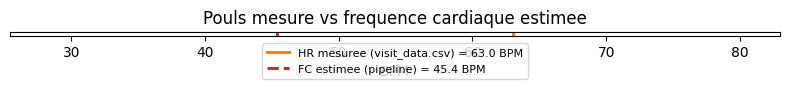

In [9]:
fig, ax = plt.subplots(figsize=(8, 1.8))
ax.axvline(hr_bpm, color="C1", lw=2.2, label=f"HR mesuree (visit_data.csv) = {hr_bpm:.1f} BPM")
ax.axvline(cardiac_bpm, color="C3", lw=2.2, ls="--", label=f"FC estimee (pipeline) = {cardiac_bpm:.1f} BPM")
lo = min(hr_bpm, cardiac_bpm) - 20
hi = max(hr_bpm, cardiac_bpm) + 20
ax.set_xlim(lo, hi)
ax.set_yticks([])
ax.set_xlabel("BPM")
ax.set_title("Pouls mesure vs frequence cardiaque estimee")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.6), ncol=1)
fig.tight_layout()


## A. Masque de selection des pixels

Image moyennee de la video recalee, avec :
- en bleu : l'intersection du masque de choroide dans le temps (tous les pixels
  qui sont DANS le masque sur TOUTES les frames) ;
- en rouge : la ROI effectivement utilisee pour les traces pixel, apres
  restriction `col_frac`/`row_frac` (tiers central des A-scans x tiers
  superieur de la choroide, cf. `PixelTraceConfig`).

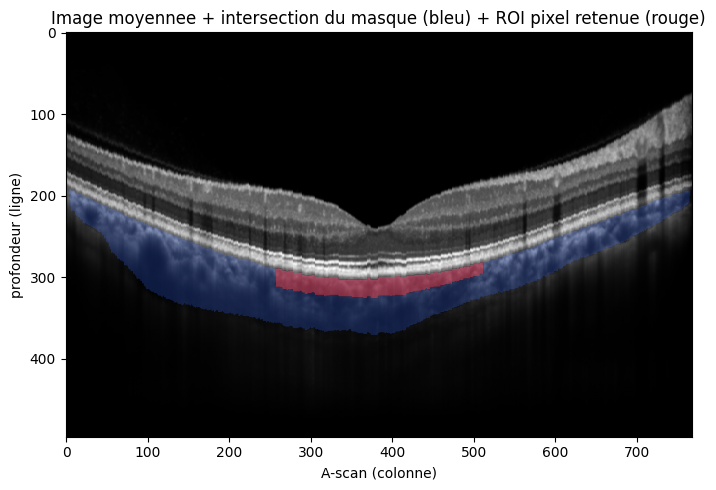

In [10]:
mean_frame = d["mean_frame"]
roi_full = d["roi_full_intersection"]
roi_sel = d["roi_selected"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(mean_frame, cmap="gray")
overlay_full = np.zeros((*roi_full.shape, 4))
overlay_full[roi_full] = (0.2, 0.4, 1.0, 0.25)
ax.imshow(overlay_full)
overlay_sel = np.zeros((*roi_sel.shape, 4))
overlay_sel[roi_sel] = (1.0, 0.2, 0.2, 0.45)
ax.imshow(overlay_sel)
ax.set_title("Image moyennee + intersection du masque (bleu) + ROI pixel retenue (rouge)")
ax.set_xlabel("A-scan (colonne)")
ax.set_ylabel("profondeur (ligne)")
fig.tight_layout()


## B. Vecteurs singuliers (SVD), domaine temporel et frequentiel

`svd_time_values` : chaque colonne est une composante SVD (U*S), calculee SANS
passe-bande (SVD sur `interpolated_signal`, pas `filtered_signal`) et SANS
normalisation des donnees (`DecompositionConfig(normalize=False)`). A droite,
la puissance Lomb-Scargle de chaque composante (meme grille de frequences que
l'estimation du rythme), avec son pic marque. Les composantes retenues comme
candidates pour l'optimisation (`selected_indices`) sont surlignees.

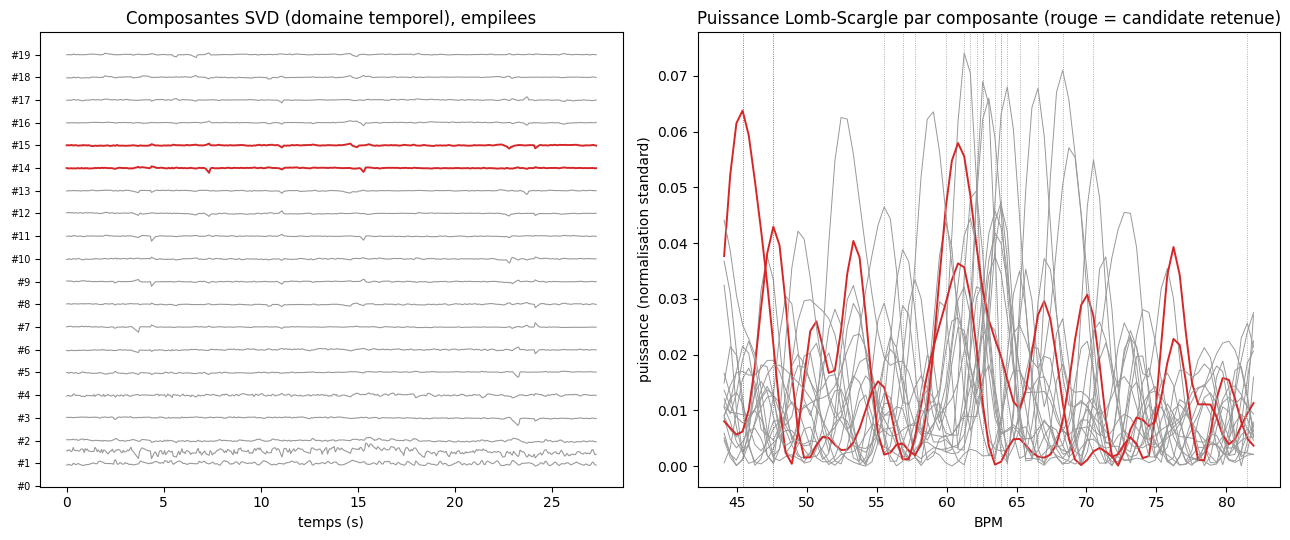

In [11]:
svd_t = d["svd_uniform_time"]
svd_v = d["svd_time_values"]           # (T_kept, K)
freqs = d["freqs"]                      # (n_freqs,)
svd_power = d["svd_power"]              # (n_freqs, K)
svd_peak_freq = d["svd_peak_freq"]
svd_concentration = d["svd_concentration"]
selected = set(d["selected_indices"].tolist())
K = svd_v.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

offsets = np.arange(K) * (3 * np.nanstd(svd_v))
for k in range(K):
    color = "C3" if k in selected else "0.6"
    lw = 1.4 if k in selected else 0.8
    axes[0].plot(svd_t, svd_v[:, k] + offsets[k], color=color, lw=lw)
axes[0].set_title("Composantes SVD (domaine temporel), empilees")
axes[0].set_xlabel("temps (s)")
axes[0].set_yticks(offsets)
axes[0].set_yticklabels([f"#{k}" for k in range(K)], fontsize=7)

bpm = freqs * 60.0
for k in range(K):
    color = "C3" if k in selected else "0.6"
    lw = 1.4 if k in selected else 0.7
    axes[1].plot(bpm, svd_power[:, k], color=color, lw=lw)
    axes[1].axvline(svd_peak_freq[k] * 60.0, color=color, lw=0.6, ls=":")
axes[1].set_title("Puissance Lomb-Scargle par composante (rouge = candidate retenue)")
axes[1].set_xlabel("BPM")
axes[1].set_ylabel("puissance (normalisation standard)")

fig.tight_layout()


## C. Combinaison optimisee des vecteurs singuliers

Signal agrege par `OptimizedSpectralCombination` (combinaison lineaire, norme
unite, des composantes SVD retenues -- poids `weights`), dans le domaine
temporel puis frequentiel. La bande utilisee pour l'optimisation
(`in_band_mask`, +/- `accept_tol_bpm` autour de la frequence cardiaque
estimee) est ombree, le pic de frequence cardiaque cible est marque, et le
pouls mesure (`visit_data.csv`) est superpose pour comparaison directe --
en frequence (ligne verticale) et en temps (grille aux multiples de la
periode mesuree).

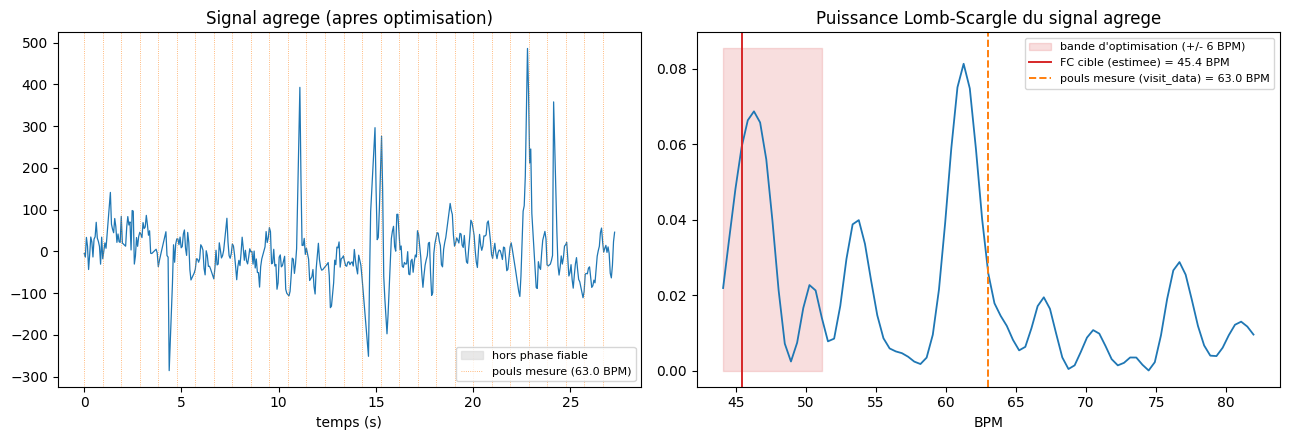

In [12]:
uniform_time = d["uniform_time"]
combined = d["combined_uniform"]
good_u = d["good_uniform"]
combined_power = d["combined_power"]
in_band = d["in_band_mask"]
accept_tol_bpm = float(d["accept_tol_bpm"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(uniform_time, combined, color="C0", lw=0.9)
axes[0].fill_between(
    uniform_time, np.nanmin(combined), np.nanmax(combined),
    where=~good_u, color="0.85", alpha=0.6, step="mid",
    label="hors phase fiable",
)
# grille aux multiples de la periode mesuree (visit_data.csv) : permet de voir
# si les battements du signal agrege tombent pres de ce rythme mesure.
period_s = 60.0 / hr_bpm if hr_bpm > 0 else np.nan
if np.isfinite(period_s) and period_s > 0:
    t0 = uniform_time[0]
    n_periods = int(np.floor((uniform_time[-1] - t0) / period_s)) + 1
    for k in range(n_periods):
        axes[0].axvline(
            t0 + k * period_s, color="C1", lw=0.6, ls=":", alpha=0.7,
            label=f"pouls mesure ({hr_bpm:.1f} BPM)" if k == 0 else None,
        )
axes[0].set_title("Signal agrege (apres optimisation)")
axes[0].set_xlabel("temps (s)")
axes[0].legend(fontsize=8)

bpm = freqs * 60.0
axes[1].plot(bpm, combined_power, color="C0", lw=1.3)
axes[1].fill_between(
    bpm, 0, combined_power.max() * 1.05, where=in_band,
    color="C3", alpha=0.15, label=f"bande d'optimisation (+/- {accept_tol_bpm:.0f} BPM)",
)
axes[1].axvline(cardiac_bpm, color="C3", lw=1.4, label=f"FC cible (estimee) = {cardiac_bpm:.1f} BPM")
axes[1].axvline(hr_bpm, color="C1", lw=1.4, ls="--", label=f"pouls mesure (visit_data) = {hr_bpm:.1f} BPM")
axes[1].set_title("Puissance Lomb-Scargle du signal agrege")
axes[1].set_xlabel("BPM")
axes[1].legend(fontsize=8)

fig.tight_layout()


## D. Phase obtenue par Hilbert

Phase instantanee (transformee de Hilbert du signal agrege), sur la grille
uniforme, et frequence cardiaque instantanee derivee (`inst_bpm`). Les
segments hors phase fiable (`good_uniform` faux) sont ombres.

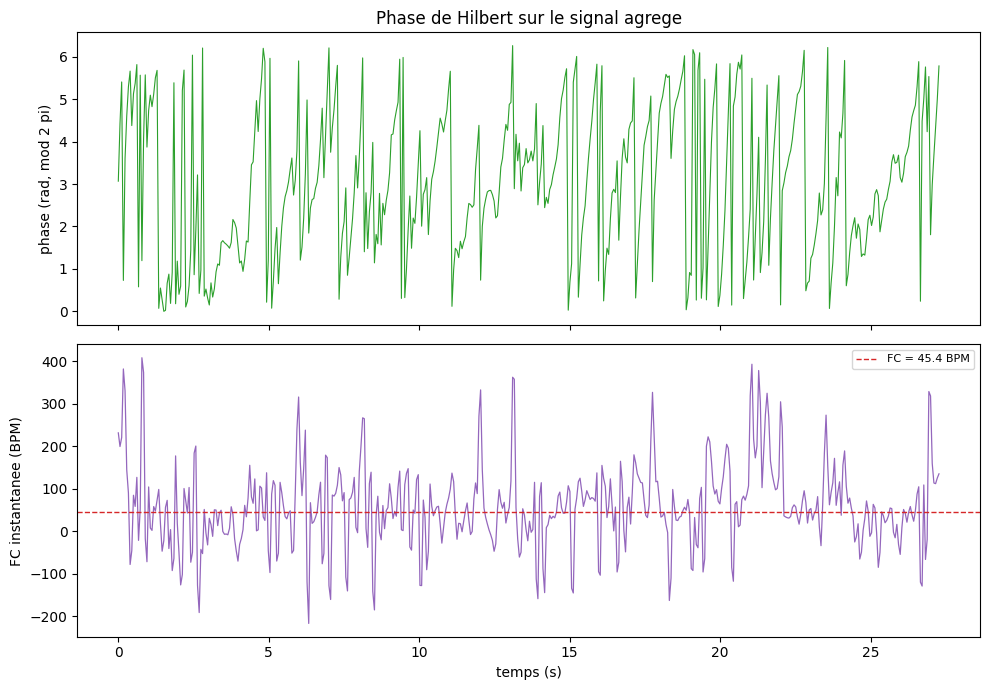

In [13]:
phase_uniform = d["phase_uniform"]
inst_bpm = d["inst_bpm"]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(uniform_time, phase_uniform, color="C2", lw=0.8)
axes[0].fill_between(
    uniform_time, 0, 2 * np.pi, where=~good_u, color="0.85", alpha=0.6, step="mid",
)
axes[0].set_ylabel("phase (rad, mod 2 pi)")
axes[0].set_title("Phase de Hilbert sur le signal agrege")

axes[1].plot(uniform_time, inst_bpm, color="C4", lw=0.9)
axes[1].axhline(cardiac_bpm, color="C3", lw=1.0, ls="--", label=f"FC = {cardiac_bpm:.1f} BPM")
axes[1].fill_between(
    uniform_time, np.nanmin(inst_bpm), np.nanmax(inst_bpm), where=~good_u,
    color="0.85", alpha=0.6, step="mid",
)
axes[1].set_ylabel("FC instantanee (BPM)")
axes[1].set_xlabel("temps (s)")
axes[1].legend(fontsize=8)

fig.tight_layout()


## E. Video one-cycle

Repliement de `registered_frames` par phase (`NCycleReconstructor`, phase de
la section D) en `n_bins x n_cycle` frames moyennees/mediannees --
`one_cycle.mp4`, ecrite par `compute_one_cycle_pixel_svd.py` a cote du
fichier de diagnostics (meme dossier que `NPZ_PATH`).

In [ ]:
from IPython.display import Video

ONE_CYCLE_PATH = NPZ_PATH.parent / "one_cycle.mp4"
print(f"Video one-cycle : {ONE_CYCLE_PATH} ({ONE_CYCLE_PATH.stat().st_size / 1e6:.2f} Mo)")
Video(str(ONE_CYCLE_PATH), embed=True, html_attributes="controls loop", width=500)
